In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
orders_df = pd.read_csv("olist_orders_dataset.csv")
customers_df = pd.read_csv("olist_customers_dataset.csv")
order_items_df = pd.read_csv("olist_order_items_dataset.csv")

print("Orders:", orders_df.shape)
print("Customers:", customers_df.shape)
print("Order items:", order_items_df.shape)

Orders: (99441, 8)
Customers: (99441, 5)
Order items: (112650, 7)


In [3]:
conn = sqlite3.connect("olist.db")

In [4]:
pd.read_sql_query("""
SELECT name
FROM sqlite_master
WHERE type = 'table';
""", conn)

,name
0,orders
1,customers
2,order_items


# delivered_orders View

In [5]:
conn.execute("DROP VIEW IF EXISTS delivered_orders")

conn.execute("""
CREATE TEMP VIEW delivered_orders AS
SELECT
    o.order_id,
    o.customer_id,
    c.customer_unique_id,
    o.order_purchase_timestamp,
    strftime('%Y-%m', o.order_purchase_timestamp) AS order_month
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered';
""")

conn.commit()

In [6]:
pd.read_sql_query("""
SELECT COUNT(*) AS total
FROM delivered_orders;
""", conn)

,total
0,96478


# Q1 — Delivered Orders

In [7]:
q1 = """
SELECT
    o.order_id,
    o.customer_id,
    c.customer_unique_id,
    o.order_purchase_timestamp,
    strftime('%Y-%m', o.order_purchase_timestamp) AS order_month
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered';
"""

delivered_orders_df = pd.read_sql_query(q1, conn)

delivered_orders_df.head()

,order_id,customer_id,customer_unique_id,order_purchase_timestamp,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018-02


# Q2 - Cohort Assignment

In [8]:
q2 = """
WITH customer_cohort AS (
    SELECT
        customer_unique_id,
        MIN(order_month) OVER (
            PARTITION BY customer_unique_id
        ) AS cohort_month
    FROM delivered_orders
)

SELECT DISTINCT
    customer_unique_id,
    cohort_month
FROM customer_cohort
ORDER BY cohort_month, customer_unique_id;
"""

cohort = pd.read_sql_query(q2, conn)

cohort.head(20)

,customer_unique_id,cohort_month
0,830d5b7aaa3b6f1e9ad63703bec97d23,2016-09
1,0032c76b20340da25249092a268ce66c,2016-10
2,01f156677184504063bd19739f924af1,2016-10
3,0636d30c77f0f9cfad81f1c9b58c791f,2016-10
4,06bdfbbe1857c3c925ec81abfb1c9666,2016-10
5,0829f7df6577d5a4b65439bea701405f,2016-10
6,08da95f931937b2c20f5225f2e6c93b0,2016-10
7,0922f37485310929b1b94e8f0c984ca5,2016-10
8,0a02ba4243b1b0e048a3841d5758d113,2016-10
9,0ac6c084c9623a0e2ace60297ad24d6c,2016-10


# Q3 - Customer Activity

In [9]:
q3 = """
SELECT DISTINCT
    customer_unique_id,
    order_id,
    order_month
FROM delivered_orders
ORDER BY customer_unique_id, order_month;
"""

activity = pd.read_sql_query(q3, conn)

activity.head(20)

,customer_unique_id,order_id,order_month
0,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,2018-05
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,2018-05
2,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,2017-03
3,0000f6ccb0745a6a4b88665a16c9f078,41272756ecddd9a9ed0180413cc22fb6,2017-10
4,0004aac84e0df4da2b147fca70cf8255,d957021f1127559cd947b62533f484f7,2017-11
5,0004bd2a26a76fe21f786e4fbd80607f,3e470077b690ea3e3d501cffb5e0c499,2018-04
6,00050ab1314c0e55a6ca13cf7181fecf,d0028facea13f508e880202d7097a5a1,2018-04
7,00053a61a98854899e70ed204dd4bafe,44e608f2db00c74a1fe329de44416a4e,2018-02
8,0005e1862207bf6ccc02e4228effd9a0,ae76bef74b97bcb0b3e355e60d9a6f9c,2017-03
9,0005ef4cd20d2893f0d9fbd94d3c0d97,01b330808c5819a6a3cb79b72f0b8288,2018-03


# Q4 - Period Number

In [10]:
q4 = """
WITH cohort AS (
    SELECT
        customer_unique_id,
        MIN(order_month) AS cohort_month
    FROM delivered_orders
    GROUP BY customer_unique_id
),

activity AS (
    SELECT DISTINCT
        customer_unique_id,
        order_id,
        order_month
    FROM delivered_orders
)

SELECT
    a.customer_unique_id,
    a.order_id,
    c.cohort_month,
    a.order_month,

    (
        (CAST(strftime('%Y', a.order_month || '-01') AS INTEGER) -
         CAST(strftime('%Y', c.cohort_month || '-01') AS INTEGER)) * 12
        +
        (CAST(strftime('%m', a.order_month || '-01') AS INTEGER) -
         CAST(strftime('%m', c.cohort_month || '-01') AS INTEGER))
    ) AS period_number

FROM activity a
JOIN cohort c
    ON a.customer_unique_id = c.customer_unique_id

ORDER BY
    c.cohort_month,
    a.customer_unique_id,
    a.order_month;
"""

customer_periods = pd.read_sql_query(q4, conn)

customer_periods.head(20)

,customer_unique_id,order_id,cohort_month,order_month,period_number
0,830d5b7aaa3b6f1e9ad63703bec97d23,bfbd0f9bdef84302105ad712db648a6c,2016-09,2016-09,0
1,0032c76b20340da25249092a268ce66c,59fa27082bb77c5dbd8a6568f3b34380,2016-10,2016-10,0
2,01f156677184504063bd19739f924af1,d3f7c0e804b501782903f7af749eb797,2016-10,2016-10,0
3,0636d30c77f0f9cfad81f1c9b58c791f,6335afd8e6b7eb0ebc8bb71ea0008f6f,2016-10,2016-10,0
4,06bdfbbe1857c3c925ec81abfb1c9666,a8c3f65a43b2e956cbfca10db4300853,2016-10,2016-10,0
5,0829f7df6577d5a4b65439bea701405f,3f72d2b757e725cd48a4726f831c7789,2016-10,2016-10,0
6,08da95f931937b2c20f5225f2e6c93b0,2fbb05b3ee700e1897b9fa501e416005,2016-10,2016-10,0
7,0922f37485310929b1b94e8f0c984ca5,ed90ba41c41da31da8e891ff43a584d1,2016-10,2016-10,0
8,0a02ba4243b1b0e048a3841d5758d113,e9555dc20eba7e4e62210df1f438ea00,2016-10,2016-10,0
9,0ac6c084c9623a0e2ace60297ad24d6c,19feb5627c41ea1b36a8e50a469b3644,2016-10,2016-10,0


# Q5 — Retention Matrix

In [11]:
q5 = """
WITH cohort AS (
    SELECT
        customer_unique_id,
        MIN(order_month) AS cohort_month
    FROM delivered_orders
    GROUP BY customer_unique_id
),

activity AS (
    SELECT DISTINCT
        customer_unique_id,
        order_id,
        order_month
    FROM delivered_orders
),

customer_periods AS (
    SELECT
        a.customer_unique_id,
        c.cohort_month,

        (
            (CAST(strftime('%Y', a.order_month || '-01') AS INTEGER) -
             CAST(strftime('%Y', c.cohort_month || '-01') AS INTEGER)) * 12
            +
            (CAST(strftime('%m', a.order_month || '-01') AS INTEGER) -
             CAST(strftime('%m', c.cohort_month || '-01') AS INTEGER))
        ) AS period_number

    FROM activity a
    JOIN cohort c
        ON a.customer_unique_id = c.customer_unique_id
)

SELECT
    cohort_month,

    COUNT(DISTINCT CASE WHEN period_number = 0 THEN customer_unique_id END) AS period_0,
    COUNT(DISTINCT CASE WHEN period_number = 1 THEN customer_unique_id END) AS period_1,
    COUNT(DISTINCT CASE WHEN period_number = 2 THEN customer_unique_id END) AS period_2,
    COUNT(DISTINCT CASE WHEN period_number = 3 THEN customer_unique_id END) AS period_3,
    COUNT(DISTINCT CASE WHEN period_number = 4 THEN customer_unique_id END) AS period_4,
    COUNT(DISTINCT CASE WHEN period_number = 5 THEN customer_unique_id END) AS period_5,
    COUNT(DISTINCT CASE WHEN period_number = 6 THEN customer_unique_id END) AS period_6,
    COUNT(DISTINCT CASE WHEN period_number = 7 THEN customer_unique_id END) AS period_7,
    COUNT(DISTINCT CASE WHEN period_number = 8 THEN customer_unique_id END) AS period_8,
    COUNT(DISTINCT CASE WHEN period_number = 9 THEN customer_unique_id END) AS period_9,
    COUNT(DISTINCT CASE WHEN period_number = 10 THEN customer_unique_id END) AS period_10,
    COUNT(DISTINCT CASE WHEN period_number = 11 THEN customer_unique_id END) AS period_11

FROM customer_periods

GROUP BY cohort_month

ORDER BY cohort_month;
"""

retention_matrix = pd.read_sql_query(q5, conn)

retention_matrix

,cohort_month,period_0,period_1,period_2,period_3,period_4,period_5,period_6,period_7,period_8,period_9,period_10,period_11
0,2016-09,1,0,0,0,0,0,0,0,0,0,0,0
1,2016-10,262,0,0,0,0,0,1,0,0,1,0,1
2,2016-12,1,1,0,0,0,0,0,0,0,0,0,0
3,2017-01,717,2,2,1,3,1,3,1,1,0,3,1
4,2017-02,1628,3,5,2,7,2,4,3,2,3,2,5
5,2017-03,2503,11,9,10,9,4,4,8,8,2,9,3
6,2017-04,2256,14,5,4,6,6,8,7,7,4,6,2
7,2017-05,3451,16,16,10,10,11,14,5,9,9,9,12
8,2017-06,3037,15,12,13,9,12,11,7,4,6,9,11
9,2017-07,3752,20,13,9,11,8,12,4,7,10,8,11


# Q6 — Cohort Sizes

In [12]:
q6 = """
WITH cohort AS (
    SELECT
        customer_unique_id,
        MIN(order_month) AS cohort_month
    FROM delivered_orders
    GROUP BY customer_unique_id
)

SELECT
    cohort_month,
    COUNT(DISTINCT customer_unique_id) AS cohort_size
FROM cohort
GROUP BY cohort_month
ORDER BY cohort_month;
"""

cohort_sizes = pd.read_sql_query(q6, conn)

cohort_sizes

,cohort_month,cohort_size
0,2016-09,1
1,2016-10,262
2,2016-12,1
3,2017-01,717
4,2017-02,1628
5,2017-03,2503
6,2017-04,2256
7,2017-05,3451
8,2017-06,3037
9,2017-07,3752


# Q7 — Retention Rate

In [13]:
q7 = """
WITH cohort AS (
    SELECT
        customer_unique_id,
        MIN(order_month) AS cohort_month
    FROM delivered_orders
    GROUP BY customer_unique_id
),

activity AS (
    SELECT DISTINCT
        customer_unique_id,
        order_id,
        order_month
    FROM delivered_orders
),

customer_periods AS (
    SELECT
        a.customer_unique_id,
        c.cohort_month,

        (
            (CAST(strftime('%Y', a.order_month || '-01') AS INTEGER) -
             CAST(strftime('%Y', c.cohort_month || '-01') AS INTEGER)) * 12
            +
            (CAST(strftime('%m', a.order_month || '-01') AS INTEGER) -
             CAST(strftime('%m', c.cohort_month || '-01') AS INTEGER))
        ) AS period_number

    FROM activity a
    JOIN cohort c
        ON a.customer_unique_id = c.customer_unique_id
),

cohort_counts AS (
    SELECT
        cohort_month,

        COUNT(DISTINCT CASE WHEN period_number = 0 THEN customer_unique_id END) AS cohort_size,
        COUNT(DISTINCT CASE WHEN period_number = 1 THEN customer_unique_id END) AS period_1,
        COUNT(DISTINCT CASE WHEN period_number = 2 THEN customer_unique_id END) AS period_2,
        COUNT(DISTINCT CASE WHEN period_number = 3 THEN customer_unique_id END) AS period_3,
        COUNT(DISTINCT CASE WHEN period_number = 4 THEN customer_unique_id END) AS period_4,
        COUNT(DISTINCT CASE WHEN period_number = 5 THEN customer_unique_id END) AS period_5,
        COUNT(DISTINCT CASE WHEN period_number = 6 THEN customer_unique_id END) AS period_6,
        COUNT(DISTINCT CASE WHEN period_number = 7 THEN customer_unique_id END) AS period_7,
        COUNT(DISTINCT CASE WHEN period_number = 8 THEN customer_unique_id END) AS period_8,
        COUNT(DISTINCT CASE WHEN period_number = 9 THEN customer_unique_id END) AS period_9,
        COUNT(DISTINCT CASE WHEN period_number = 10 THEN customer_unique_id END) AS period_10,
        COUNT(DISTINCT CASE WHEN period_number = 11 THEN customer_unique_id END) AS period_11

    FROM customer_periods
    GROUP BY cohort_month
)

SELECT
    cohort_month,

    100.0 AS period_0,

    ROUND(100.0 * period_1 / cohort_size, 2) AS period_1,
    ROUND(100.0 * period_2 / cohort_size, 2) AS period_2,
    ROUND(100.0 * period_3 / cohort_size, 2) AS period_3,
    ROUND(100.0 * period_4 / cohort_size, 2) AS period_4,
    ROUND(100.0 * period_5 / cohort_size, 2) AS period_5,
    ROUND(100.0 * period_6 / cohort_size, 2) AS period_6,
    ROUND(100.0 * period_7 / cohort_size, 2) AS period_7,
    ROUND(100.0 * period_8 / cohort_size, 2) AS period_8,
    ROUND(100.0 * period_9 / cohort_size, 2) AS period_9,
    ROUND(100.0 * period_10 / cohort_size, 2) AS period_10,
    ROUND(100.0 * period_11 / cohort_size, 2) AS period_11

FROM cohort_counts
ORDER BY cohort_month;
"""

retention_rate = pd.read_sql_query(q7, conn)

retention_rate

,cohort_month,period_0,period_1,period_2,period_3,period_4,period_5,period_6,period_7,period_8,period_9,period_10,period_11
0,2016-09,100.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,2016-10,100.0,0.00,0.00,0.00,0.00,0.00,0.38,0.00,0.00,0.38,0.00,0.38
2,2016-12,100.0,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,2017-01,100.0,0.28,0.28,0.14,0.42,0.14,0.42,0.14,0.14,0.00,0.42,0.14
4,2017-02,100.0,0.18,0.31,0.12,0.43,0.12,0.25,0.18,0.12,0.18,0.12,0.31
5,2017-03,100.0,0.44,0.36,0.40,0.36,0.16,0.16,0.32,0.32,0.08,0.36,0.12
6,2017-04,100.0,0.62,0.22,0.18,0.27,0.27,0.35,0.31,0.31,0.18,0.27,0.09
7,2017-05,100.0,0.46,0.46,0.29,0.29,0.32,0.41,0.14,0.26,0.26,0.26,0.35
8,2017-06,100.0,0.49,0.40,0.43,0.30,0.40,0.36,0.23,0.13,0.20,0.30,0.36
9,2017-07,100.0,0.53,0.35,0.24,0.29,0.21,0.32,0.11,0.19,0.27,0.21,0.29


# Q8 — Average Retention

In [14]:
q8 = """
WITH cohort AS (
    SELECT
        customer_unique_id,
        MIN(order_month) AS cohort_month
    FROM delivered_orders
    GROUP BY customer_unique_id
),

activity AS (
    SELECT DISTINCT
        customer_unique_id,
        order_id,
        order_month
    FROM delivered_orders
),

customer_periods AS (
    SELECT
        a.customer_unique_id,
        c.cohort_month,

        (
            (CAST(strftime('%Y', a.order_month || '-01') AS INTEGER) -
             CAST(strftime('%Y', c.cohort_month || '-01') AS INTEGER)) * 12
            +
            (CAST(strftime('%m', a.order_month || '-01') AS INTEGER) -
             CAST(strftime('%m', c.cohort_month || '-01') AS INTEGER))
        ) AS period_number

    FROM activity a
    JOIN cohort c
        ON a.customer_unique_id = c.customer_unique_id
),

retention AS (
    SELECT
        cohort_month,
        period_number,
        COUNT(DISTINCT customer_unique_id) AS active_customers
    FROM customer_periods
    GROUP BY cohort_month, period_number
),

cohort_size AS (
    SELECT
        cohort_month,
        MAX(
            CASE
                WHEN period_number = 0
                THEN active_customers
            END
        ) AS cohort_size
    FROM retention
    GROUP BY cohort_month
)

SELECT
    r.period_number,

    ROUND(
        AVG(
            100.0 * r.active_customers / cs.cohort_size
        ),
        2
    ) AS avg_retention_rate

FROM retention r
JOIN cohort_size cs
    ON r.cohort_month = cs.cohort_month

GROUP BY r.period_number
ORDER BY r.period_number;
"""

avg_retention = pd.read_sql_query(q8, conn)

avg_retention

,period_number,avg_retention_rate
0,0,100.00
1,1,5.45
2,2,0.34
3,3,0.25
4,4,0.29
5,5,0.23
6,6,0.27
7,7,0.21
8,8,0.21
9,9,0.19


# Q9 — Best / Worst Cohort

In [15]:
q9 = """
WITH cohort AS (
    SELECT
        customer_unique_id,
        MIN(order_month) AS cohort_month
    FROM delivered_orders
    GROUP BY customer_unique_id
),

activity AS (
    SELECT DISTINCT
        customer_unique_id,
        order_id,
        order_month
    FROM delivered_orders
),

customer_periods AS (
    SELECT
        a.customer_unique_id,
        c.cohort_month,

        (
            (CAST(strftime('%Y', a.order_month || '-01') AS INTEGER) -
             CAST(strftime('%Y', c.cohort_month || '-01') AS INTEGER)) * 12
            +
            (CAST(strftime('%m', a.order_month || '-01') AS INTEGER) -
             CAST(strftime('%m', c.cohort_month || '-01') AS INTEGER))
        ) AS period_number

    FROM activity a
    JOIN cohort c
        ON a.customer_unique_id = c.customer_unique_id
),

cohort_counts AS (
    SELECT
        cohort_month,

        COUNT(DISTINCT CASE
            WHEN period_number = 0
            THEN customer_unique_id
        END) AS cohort_size,

        COUNT(DISTINCT CASE
            WHEN period_number = 1
            THEN customer_unique_id
        END) AS period_1_customers

    FROM customer_periods
    GROUP BY cohort_month
)

SELECT
    cohort_month,
    cohort_size,
    period_1_customers,

    ROUND(
        100.0 * period_1_customers / cohort_size,
        2
    ) AS period_1_retention

FROM cohort_counts
ORDER BY period_1_retention DESC;
"""

q9_result = pd.read_sql_query(q9, conn)

q9_result

,cohort_month,cohort_size,period_1_customers,period_1_retention
0,2016-12,1,1,100.00
1,2017-10,4328,31,0.72
2,2017-09,4004,28,0.70
3,2017-08,4057,28,0.69
4,2017-04,2256,14,0.62
5,2018-04,6582,39,0.59
6,2017-11,7060,40,0.57
7,2017-07,3752,20,0.53
8,2018-05,6506,34,0.52
9,2018-07,5949,31,0.52


In [16]:
q9_result.head(1)

,cohort_month,cohort_size,period_1_customers,period_1_retention
0,2016-12,1,1,100.0


In [17]:
q9_result.tail(1)

,cohort_month,cohort_size,period_1_customers,period_1_retention
22,2018-08,6144,0,0.0


# Q10.1 — Cohort Calculation

In [26]:
q10_1 = """
WITH delivered_orders AS (
    SELECT
        o.order_id,
        c.customer_unique_id,
        o.order_purchase_timestamp
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
)

SELECT
    customer_unique_id,
    strftime('%Y-%m', MIN(order_purchase_timestamp)) AS cohort_month
FROM delivered_orders
GROUP BY customer_unique_id
ORDER BY cohort_month
LIMIT 20;
"""

q10_1_result = pd.read_sql_query(q10_1, conn)

print("Rows:", len(q10_1_result))
q10_1_result

Rows: 20


,customer_unique_id,cohort_month
0,830d5b7aaa3b6f1e9ad63703bec97d23,2016-09
1,0032c76b20340da25249092a268ce66c,2016-10
2,01f156677184504063bd19739f924af1,2016-10
3,0636d30c77f0f9cfad81f1c9b58c791f,2016-10
4,06bdfbbe1857c3c925ec81abfb1c9666,2016-10
5,0829f7df6577d5a4b65439bea701405f,2016-10
6,08da95f931937b2c20f5225f2e6c93b0,2016-10
7,0922f37485310929b1b94e8f0c984ca5,2016-10
8,0a02ba4243b1b0e048a3841d5758d113,2016-10
9,0ac6c084c9623a0e2ace60297ad24d6c,2016-10


# Q10.2 — Cohort Assignment

In [27]:
q10_2 = """
WITH delivered_orders AS (
    SELECT
        o.order_id,
        c.customer_unique_id,
        o.order_purchase_timestamp
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),

customer_cohorts AS (
    SELECT
        customer_unique_id,
        strftime('%Y-%m', MIN(order_purchase_timestamp)) AS cohort_month
    FROM delivered_orders
    GROUP BY customer_unique_id
)

SELECT
    d.order_id,
    d.customer_unique_id,
    cc.cohort_month,
    d.order_purchase_timestamp
FROM delivered_orders d
JOIN customer_cohorts cc
    ON d.customer_unique_id = cc.customer_unique_id
LIMIT 20;
"""

q10_2_result = pd.read_sql_query(q10_2, conn)

print("Rows:", len(q10_2_result))
q10_2_result

Rows: 20


,order_id,customer_unique_id,cohort_month,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-09,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02-13 21:18:39
5,a4591c265e18cb1dcee52889e2d8acc3,80bb27c7c16e8f973207a5086ab329e2,2017-07,2017-07-09 21:57:05
6,6514b8ad8028c9f2cc2374ded245783f,932afa1e708222e5821dac9cd5db4cae,2017-05,2017-05-16 13:10:30
7,76c6e866289321a7c93b82b54852dc33,39382392765b6dc74812866ee5ee92a7,2017-01,2017-01-23 18:29:09
8,e69bfb5eb88e0ed6a785585b27e16dbf,299905e3934e9e181bfb2e164dd4b4f8,2017-07,2017-07-29 11:55:02
9,e6ce16cb79ec1d90b1da9085a6118aeb,f2a85dec752b8517b5e58a06ff3cd937,2017-05,2017-05-16 19:41:10


# Q10.3 — Order Month

In [28]:
q10_3 = """
WITH delivered_orders AS (
    SELECT
        o.order_id,
        c.customer_unique_id,
        o.order_purchase_timestamp
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),

customer_cohorts AS (
    SELECT
        customer_unique_id,
        strftime('%Y-%m', MIN(order_purchase_timestamp)) AS cohort_month
    FROM delivered_orders
    GROUP BY customer_unique_id
)

SELECT
    d.order_id,
    d.customer_unique_id,
    cc.cohort_month,
    strftime('%Y-%m', d.order_purchase_timestamp) AS order_month
FROM delivered_orders d
JOIN customer_cohorts cc
    ON d.customer_unique_id = cc.customer_unique_id
LIMIT 20;
"""

q10_3_result = pd.read_sql_query(q10_3, conn)

print("Rows:", len(q10_3_result))
q10_3_result

Rows: 20


,order_id,customer_unique_id,cohort_month,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-09,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02
5,a4591c265e18cb1dcee52889e2d8acc3,80bb27c7c16e8f973207a5086ab329e2,2017-07,2017-07
6,6514b8ad8028c9f2cc2374ded245783f,932afa1e708222e5821dac9cd5db4cae,2017-05,2017-05
7,76c6e866289321a7c93b82b54852dc33,39382392765b6dc74812866ee5ee92a7,2017-01,2017-01
8,e69bfb5eb88e0ed6a785585b27e16dbf,299905e3934e9e181bfb2e164dd4b4f8,2017-07,2017-07
9,e6ce16cb79ec1d90b1da9085a6118aeb,f2a85dec752b8517b5e58a06ff3cd937,2017-05,2017-05


# Q10.4 — Period Calculation

In [29]:
q10_4 = """
WITH delivered_orders AS (
    SELECT
        o.order_id,
        c.customer_unique_id,
        o.order_purchase_timestamp
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),

customer_cohorts AS (
    SELECT
        customer_unique_id,
        strftime('%Y-%m', MIN(order_purchase_timestamp)) AS cohort_month
    FROM delivered_orders
    GROUP BY customer_unique_id
)

SELECT
    d.order_id,
    d.customer_unique_id,
    cc.cohort_month,
    strftime('%Y-%m', d.order_purchase_timestamp) AS order_month
FROM delivered_orders d
JOIN customer_cohorts cc
    ON d.customer_unique_id = cc.customer_unique_id
LIMIT 20;
"""

q10_4_result = pd.read_sql_query(q10_4, conn)

q10_4_result["cohort_month"] = pd.to_datetime(
    q10_4_result["cohort_month"]
)

q10_4_result["order_month"] = pd.to_datetime(
    q10_4_result["order_month"]
)

q10_4_result["period_number"] = (
    (q10_4_result["order_month"].dt.year -
     q10_4_result["cohort_month"].dt.year) * 12
    +
    (q10_4_result["order_month"].dt.month -
     q10_4_result["cohort_month"].dt.month)
)

q10_4_result

,order_id,customer_unique_id,cohort_month,order_month,period_number
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-09-01,2017-10-01,1
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-01,2018-07-01,0
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-01,2018-08-01,0
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-01,2017-11-01,0
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-01,2018-02-01,0
5,a4591c265e18cb1dcee52889e2d8acc3,80bb27c7c16e8f973207a5086ab329e2,2017-07-01,2017-07-01,0
6,6514b8ad8028c9f2cc2374ded245783f,932afa1e708222e5821dac9cd5db4cae,2017-05-01,2017-05-01,0
7,76c6e866289321a7c93b82b54852dc33,39382392765b6dc74812866ee5ee92a7,2017-01-01,2017-01-01,0
8,e69bfb5eb88e0ed6a785585b27e16dbf,299905e3934e9e181bfb2e164dd4b4f8,2017-07-01,2017-07-01,0
9,e6ce16cb79ec1d90b1da9085a6118aeb,f2a85dec752b8517b5e58a06ff3cd937,2017-05-01,2017-05-01,0


# Q10.5 — Revenue Data

In [30]:
q10_5 = """
WITH delivered_orders AS (
    SELECT
        o.order_id,
        c.customer_unique_id,
        o.order_purchase_timestamp
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),

customer_cohorts AS (
    SELECT
        customer_unique_id,
        strftime('%Y-%m', MIN(order_purchase_timestamp)) AS cohort_month
    FROM delivered_orders
    GROUP BY customer_unique_id
)

SELECT
    d.order_id,
    d.customer_unique_id,
    cc.cohort_month,
    oi.price
FROM delivered_orders d
JOIN customer_cohorts cc
    ON d.customer_unique_id = cc.customer_unique_id
JOIN order_items oi
    ON d.order_id = oi.order_id
LIMIT 20;
"""

q10_5_result = pd.read_sql_query(q10_5, conn)

print("Rows:", len(q10_5_result))
q10_5_result

Rows: 20


,order_id,customer_unique_id,cohort_month,price
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-09,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,19.90
5,a4591c265e18cb1dcee52889e2d8acc3,80bb27c7c16e8f973207a5086ab329e2,2017-07,147.90
6,6514b8ad8028c9f2cc2374ded245783f,932afa1e708222e5821dac9cd5db4cae,2017-05,59.99
7,76c6e866289321a7c93b82b54852dc33,39382392765b6dc74812866ee5ee92a7,2017-01,19.90
8,e69bfb5eb88e0ed6a785585b27e16dbf,299905e3934e9e181bfb2e164dd4b4f8,2017-07,149.99
9,e6ce16cb79ec1d90b1da9085a6118aeb,f2a85dec752b8517b5e58a06ff3cd937,2017-05,99.00


# Q10.6 — Revenue Preparation

In [31]:
q10_6 = """
WITH delivered_orders AS (
    SELECT
        o.order_id,
        c.customer_unique_id,
        o.order_purchase_timestamp
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),

customer_cohorts AS (
    SELECT
        customer_unique_id,
        strftime('%Y-%m', MIN(order_purchase_timestamp)) AS cohort_month
    FROM delivered_orders
    GROUP BY customer_unique_id
)

SELECT
    d.order_id,
    d.customer_unique_id,
    cc.cohort_month,
    strftime('%Y-%m', d.order_purchase_timestamp) AS order_month,
    oi.price

FROM delivered_orders d

JOIN customer_cohorts cc
    ON d.customer_unique_id = cc.customer_unique_id

JOIN order_items oi
    ON d.order_id = oi.order_id;
"""

q10_6_result = pd.read_sql_query(q10_6, conn)

q10_6_result["cohort_month"] = pd.to_datetime(
    q10_6_result["cohort_month"]
)

q10_6_result["order_month"] = pd.to_datetime(
    q10_6_result["order_month"]
)

q10_6_result["period_number"] = (
    (q10_6_result["order_month"].dt.year -
     q10_6_result["cohort_month"].dt.year) * 12
    +
    (q10_6_result["order_month"].dt.month -
     q10_6_result["cohort_month"].dt.month)
)

print("Rows:", len(q10_6_result))

q10_6_result.head(20)

Rows: 110197


,order_id,customer_unique_id,cohort_month,order_month,price,period_number
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-09-01,2017-10-01,29.99,1
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-01,2018-07-01,118.70,0
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-01,2018-08-01,159.90,0
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-01,2017-11-01,45.00,0
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-01,2018-02-01,19.90,0
5,a4591c265e18cb1dcee52889e2d8acc3,80bb27c7c16e8f973207a5086ab329e2,2017-07-01,2017-07-01,147.90,0
6,6514b8ad8028c9f2cc2374ded245783f,932afa1e708222e5821dac9cd5db4cae,2017-05-01,2017-05-01,59.99,0
7,76c6e866289321a7c93b82b54852dc33,39382392765b6dc74812866ee5ee92a7,2017-01-01,2017-01-01,19.90,0
8,e69bfb5eb88e0ed6a785585b27e16dbf,299905e3934e9e181bfb2e164dd4b4f8,2017-07-01,2017-07-01,149.99,0
9,e6ce16cb79ec1d90b1da9085a6118aeb,f2a85dec752b8517b5e58a06ff3cd937,2017-05-01,2017-05-01,99.00,0


# Q10.7 — Revenue Analysis

In [32]:
q10_final = (
    q10_6_result
    .groupby(["cohort_month", "period_number"])
    .agg(
        total_revenue=("price", "sum"),
        active_customers=("customer_unique_id", "nunique")
    )
    .reset_index()
)

q10_final["revenue_per_customer"] = (
    q10_final["total_revenue"] /
    q10_final["active_customers"]
)

q10_final["total_revenue"] = q10_final["total_revenue"].round(2)
q10_final["revenue_per_customer"] = q10_final["revenue_per_customer"].round(2)

q10_final = q10_final.sort_values(
    ["cohort_month", "period_number"]
).reset_index(drop=True)

print("Rows:", len(q10_final))

q10_final.head(20)

Rows: 219


,cohort_month,period_number,total_revenue,active_customers,revenue_per_customer
0,2016-09-01,0,134.97,1,134.97
1,2016-10-01,0,40325.11,262,153.91
2,2016-10-01,6,99.99,1,99.99
3,2016-10-01,9,339.00,1,339.00
4,2016-10-01,11,49.00,1,49.00
5,2016-10-01,13,115.20,1,115.20
6,2016-10-01,15,298.60,1,298.60
7,2016-10-01,17,98.00,1,98.00
8,2016-10-01,19,289.28,2,144.64
9,2016-10-01,20,158.39,2,79.20


In [33]:
# Q10 summary

print("Total revenue:")
print(round(q10_final["total_revenue"].sum(), 2))

print("\nHighest revenue cohorts:")
display(
    q10_final
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

print("\nHighest revenue per customer:")
display(
    q10_final
    .sort_values("revenue_per_customer", ascending=False)
    .head(10)
)

Total revenue:
13221498.11

Highest revenue cohorts:


,cohort_month,period_number,total_revenue,active_customers,revenue_per_customer
164,2017-11-01,0,972614.06,7060,137.76
209,2018-05-01,0,953140.05,6506,146.50
204,2018-04-01,0,952665.48,6582,144.74
198,2018-03-01,0,937192.39,6774,138.35
183,2018-01-01,0,906733.35,6842,132.52
216,2018-07-01,0,847944.56,5949,142.54
213,2018-06-01,0,830699.75,5878,141.32
218,2018-08-01,0,820059.08,6144,133.47
191,2018-02-01,0,813053.18,6288,129.30
174,2017-12-01,0,709843.58,5338,132.98



Highest revenue per customer:


,cohort_month,period_number,total_revenue,active_customers,revenue_per_customer
3,2016-10-01,9,339.00,1,339.00
53,2017-03-01,5,1306.99,4,326.75
113,2017-06-01,14,2278.98,7,325.57
6,2016-10-01,15,298.60,1,298.60
82,2017-04-01,16,894.89,3,298.30
136,2017-08-01,8,1631.69,6,271.95
126,2017-07-01,12,1274.29,5,254.86
79,2017-04-01,13,252.00,1,252.00
46,2017-02-01,16,251.80,1,251.80
181,2017-12-01,7,235.90,1,235.90


# Bonus 1 — Customer Segmentation¶

In [34]:
bonus_segmentation = """
WITH customer_orders AS (
    SELECT
        customer_unique_id,
        COUNT(DISTINCT order_id) AS order_count
    FROM delivered_orders
    GROUP BY customer_unique_id
)

SELECT
    CASE
        WHEN order_count = 1 THEN 'One-time Customer'
        WHEN order_count BETWEEN 2 AND 3 THEN 'Returning Customer'
        ELSE 'Frequent Customer'
    END AS customer_segment,
    COUNT(*) AS customer_count
FROM customer_orders
GROUP BY customer_segment
ORDER BY customer_count DESC;
"""

customer_segments = pd.read_sql_query(
    bonus_segmentation,
    conn
)

customer_segments

,customer_segment,customer_count
0,One-time Customer,90557
1,Returning Customer,2754
2,Frequent Customer,47


# Bonus 2 — Cumulative Revenue per Customer

In [41]:
bonus_revenue = """
WITH customer_orders AS (
    SELECT
        d.customer_unique_id,
        d.order_id,
        d.order_purchase_timestamp,
        SUM(oi.price + oi.freight_value) AS order_revenue
    FROM delivered_orders d
    JOIN order_items oi
        ON d.order_id = oi.order_id
    GROUP BY
        d.customer_unique_id,
        d.order_id,
        d.order_purchase_timestamp
),

cumulative_revenue AS (
    SELECT
        customer_unique_id,
        order_id,
        order_purchase_timestamp,
        order_revenue,
        SUM(order_revenue) OVER (
            PARTITION BY customer_unique_id
            ORDER BY order_purchase_timestamp
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS cumulative_revenue
    FROM customer_orders
)

SELECT
    customer_unique_id,
    order_id,
    order_purchase_timestamp,
    ROUND(order_revenue, 2) AS order_revenue,
    ROUND(cumulative_revenue, 2) AS cumulative_revenue
FROM cumulative_revenue
ORDER BY customer_unique_id, order_purchase_timestamp;
"""

cumulative_revenue = pd.read_sql_query(
    bonus_revenue,
    conn
)

cumulative_revenue.head(20)

,customer_unique_id,order_id,order_purchase_timestamp,order_revenue,cumulative_revenue
0,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,2018-05-10 10:56:27,141.90,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,2018-05-07 11:11:27,27.19,27.19
2,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,2017-03-10 21:05:03,86.22,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,41272756ecddd9a9ed0180413cc22fb6,2017-10-12 20:29:41,43.62,43.62
4,0004aac84e0df4da2b147fca70cf8255,d957021f1127559cd947b62533f484f7,2017-11-14 19:45:42,196.89,196.89
5,0004bd2a26a76fe21f786e4fbd80607f,3e470077b690ea3e3d501cffb5e0c499,2018-04-05 19:33:16,166.98,166.98
6,00050ab1314c0e55a6ca13cf7181fecf,d0028facea13f508e880202d7097a5a1,2018-04-20 12:57:23,35.38,35.38
7,00053a61a98854899e70ed204dd4bafe,44e608f2db00c74a1fe329de44416a4e,2018-02-28 11:15:41,419.18,419.18
8,0005e1862207bf6ccc02e4228effd9a0,ae76bef74b97bcb0b3e355e60d9a6f9c,2017-03-04 23:32:12,150.12,150.12
9,0005ef4cd20d2893f0d9fbd94d3c0d97,01b330808c5819a6a3cb79b72f0b8288,2018-03-12 15:22:12,129.76,129.76


# Bonus 3 — Segmentləri vizuallaşdıraq

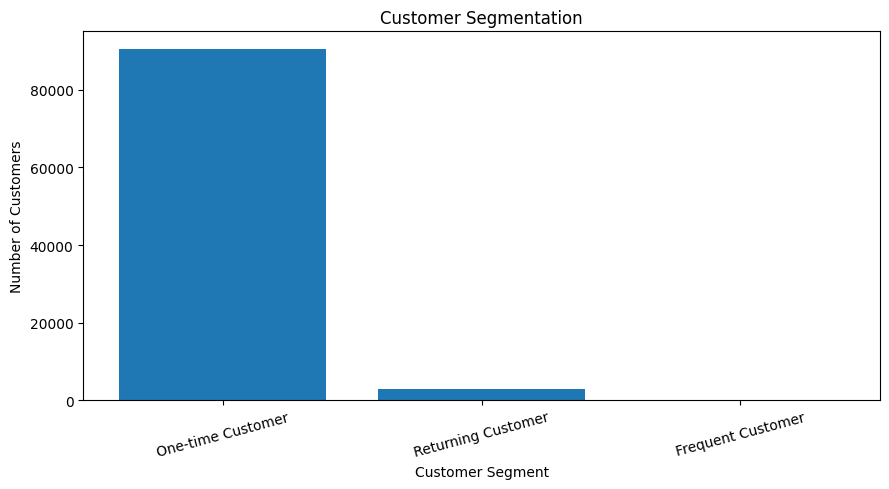

In [39]:
plt.figure(figsize=(9, 5))

plt.bar(
    customer_segments["customer_segment"],
    customer_segments["customer_count"]
)

plt.title("Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# Q11 — Retention Heatmap

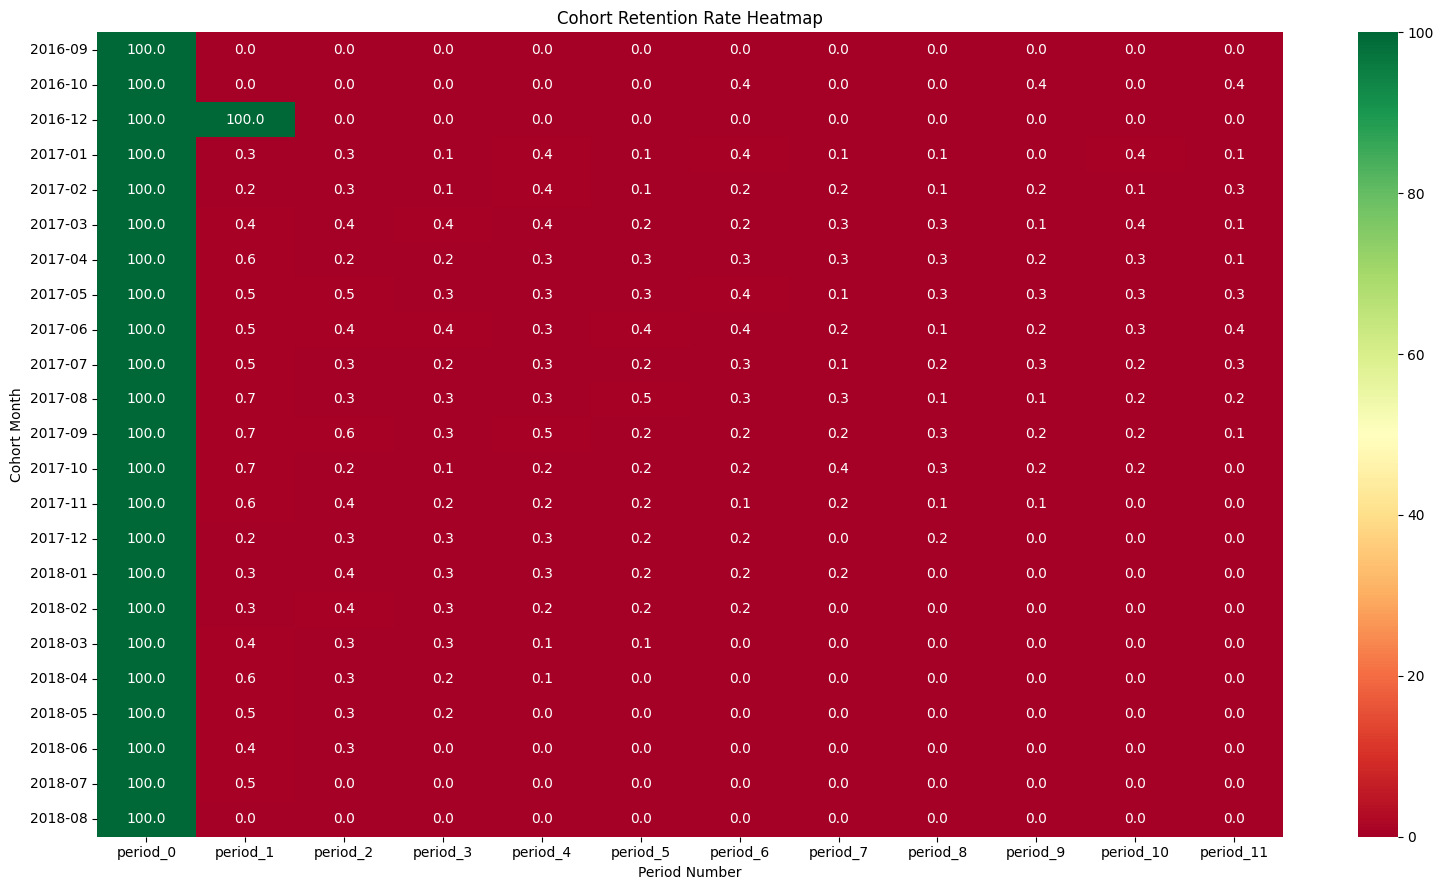

In [35]:
heatmap_data = retention_rate.set_index("cohort_month")

plt.figure(figsize=(16, 9))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    vmin=0,
    vmax=100
)

plt.title("Cohort Retention Rate Heatmap")
plt.xlabel("Period Number")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

# Q12 — Average Retention Curve

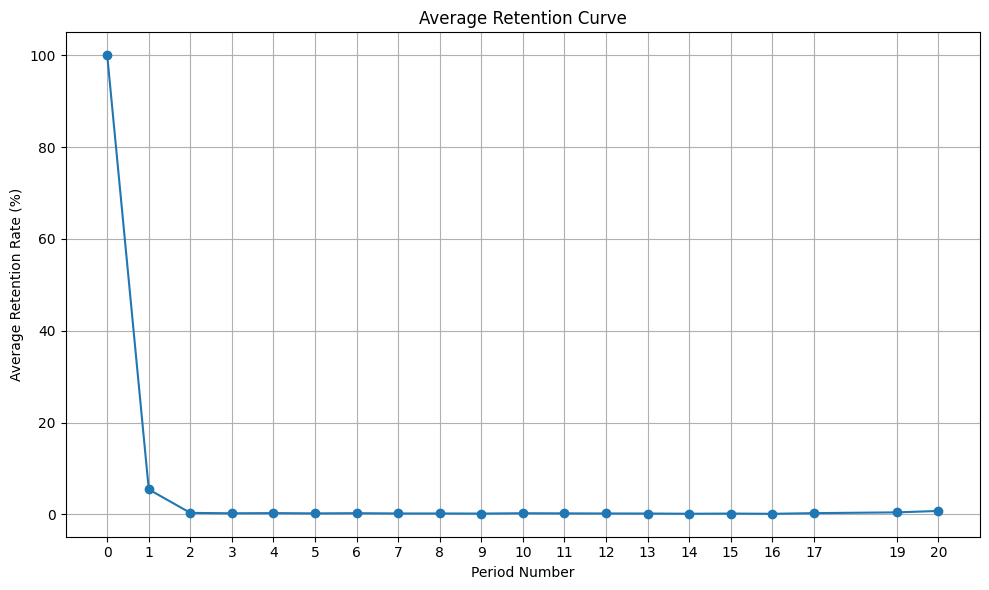

In [36]:
plt.figure(figsize=(10, 6))

plt.plot(
    avg_retention["period_number"],
    avg_retention["avg_retention_rate"],
    marker="o"
)

plt.title("Average Retention Curve")
plt.xlabel("Period Number")
plt.ylabel("Average Retention Rate (%)")
plt.xticks(avg_retention["period_number"])
plt.grid(True)

plt.tight_layout()
plt.show()

# Q13 — Cohort Size Bar Chart

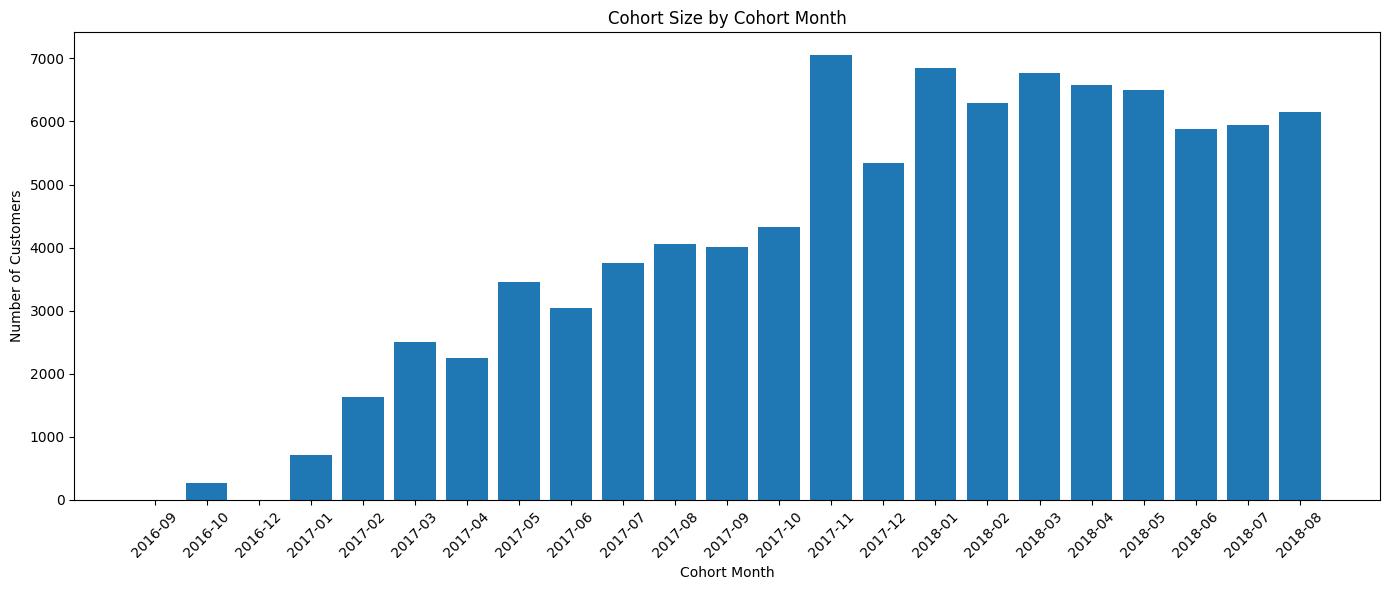

In [37]:
plt.figure(figsize=(14, 6))

plt.bar(
    cohort_sizes["cohort_month"],
    cohort_sizes["cohort_size"]
)

plt.title("Cohort Size by Cohort Month")
plt.xlabel("Cohort Month")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Q14 — Period 0 → 1 insight

In [38]:
period_0 = avg_retention.loc[
    avg_retention["period_number"] == 0,
    "avg_retention_rate"
].iloc[0]

period_1 = avg_retention.loc[
    avg_retention["period_number"] == 1,
    "avg_retention_rate"
].iloc[0]

drop = period_0 - period_1

print(f"Period 0 retention: {period_0:.2f}%")
print(f"Period 1 retention: {period_1:.2f}%")
print(f"Drop from Period 0 to Period 1: {drop:.2f} percentage points")

Period 0 retention: 100.00%
Period 1 retention: 5.45%
Drop from Period 0 to Period 1: 94.55 percentage points
